In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import umap
import hdbscan
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import PCA
from clustering.hdbscan_optimize import optimize_umap_hdbscan_n_components
from visualization.samples_plot import show_clustering_samples


PROJECT_ROOT = Path.cwd().resolve().parent
EMBEDDING_DIR = PROJECT_ROOT / "data" / "glomeruli" / "embeddings"

EMBEDDING_NAME = "densenet_crops_embeddings"

embedding: np.ndarray = np.load(EMBEDDING_DIR / f"{EMBEDDING_NAME}.npy")
csv = pd.read_csv(EMBEDDING_DIR / f"{EMBEDDING_NAME}.csv")

n_samples = embedding.shape[0]

2026-07-04 18:33:53.833770: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
embedding_l2 = Normalizer(norm="l2").fit_transform(embedding)

pca_95 = PCA(n_components=0.95)
pca_95_embedding = pca_95.fit_transform(embedding_l2)

In [12]:
best = optimize_umap_hdbscan_n_components(
    pca_95_embedding,
    [10, 15, 20, 30, 40, 50],
    n_runs=20,
    min_clusters=5,
    max_clusters=8,
    max_noise=0.33,
)

best_n_components = best["best_n_components"]

if best_n_components is None:
    raise ValueError("No suitable number of components found for UMAP.")

In [13]:
n_neighbors = int(
    np.clip(
        round(1.5 * np.sqrt(n_samples)),
        15,
        min(100, n_samples - 1),
    )
)
umap_embedding = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=0.0,
    n_components=best_n_components,
    metric="cosine",
).fit_transform(pca_95_embedding)

In [14]:
min_clusters_size = min_cluster_size = int(max(10, round(0.03 * n_samples)))
min_samples = int(
        np.clip(
            round(0.5 * min_cluster_size),
            5,
            30,
        )
    )

clustering = hdbscan.HDBSCAN(
    min_cluster_size=min_clusters_size,
    min_samples=min_samples,
    metric="euclidean",
).fit_predict(umap_embedding)

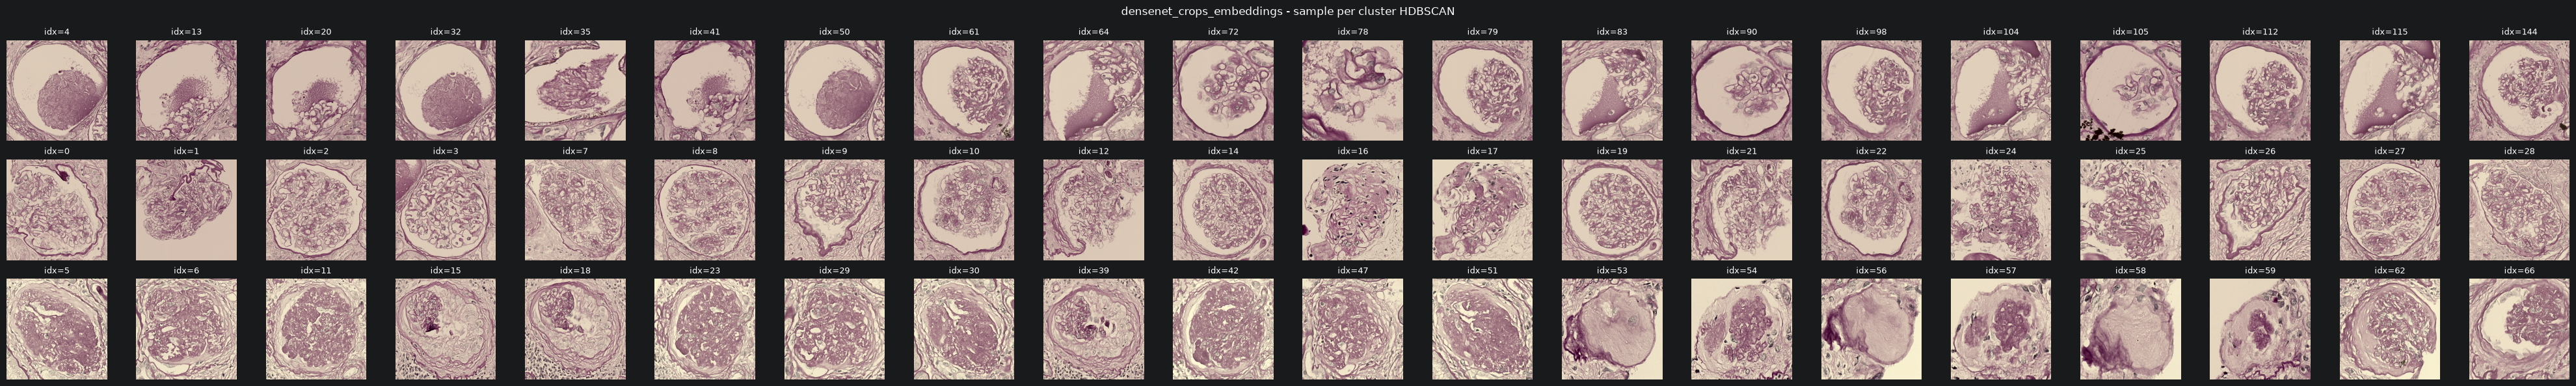

In [15]:
image_paths = csv["image_path"].tolist()

sample_figure, sample_axes = show_clustering_samples(
    labels=clustering,
    image_paths=image_paths,
    x=20,
    include_noise=False,
    base_dir=PROJECT_ROOT,
    title=f"{EMBEDDING_NAME} - sample per cluster HDBSCAN",
    image_size=2.0,
)